# Fundamentos de Support Vector Machine (SVM) y Clasificación lineal

## Intuición geométrica y el Hiperplano

El objetivo principal de una SVM en clasificación es encontrar el "mejor" límite de decisión que separe dos clases de datos. A este límite lo llamamos hiperplano. En 2D, un hiperplano es una línea; en 3D, es un plano plano; y en $N$ dimensiones, es un hiperplano $(N-1)$-dimensional.

Pero no buscamos cualquier hiperplano, buscamos el que tenga el margen máximo. El margen es la distancia entre el hiperplano y las muestras de datos más cercanas de cada clase. 

Estas muestras críticas que "sostienen" los márgenes se denominan Vectores de Soporte (Support Vectors).Matemáticamente, la ecuación del hiperplano se define como:
$$\mathbf{w} \cdot \mathbf{x} + b = 0$$
Donde, $\mathbf{w}$ es el vector de pesos (perpendicular al hiperplano), $\mathbf{x}$ es el vector de características de entrada, y $b$ es el sesgo (bias).Los dos márgenes (positivo y negativo) donde se asientan los vectores de soporte se definen como:
$$\mathbf{w} \cdot \mathbf{x} + b = 1$$
$$\mathbf{w} \cdot \mathbf{x} + b = -1$$

La distancia total entre estos dos márgenes es $\frac{2}{\|\mathbf{w}\|}$. Para maximizar este margen (y por ende la capacidad de generalización del modelo), necesitamos minimizar $\|\mathbf{w}\|$.

## Formulación Matemática: Hard Margin vs. Soft Margin

### Hard Margin (Margen Duro):

Si los datos son perfectamente separables linealmente, nuestro problema de optimización cuadrática se plantea así:
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2$$

Sujeto a la restricción geométrica de que todos los puntos estén clasificados correctamente fuera del margen:
$$y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 \quad \text{para todo } i$$

Donde, $y_i \in \{-1, 1\}$ son las etiquetas de clase).

### Soft Margin (Margen Suave) y el Parámetro C:

En el mundo real con datos como en el conjunto de datos que vamos a explorar (Wine Dataset), las clases se superponen. Un Hard Margin fallaría o se sobreajustaría (overfitting) terriblemente ante un solo valor atípico (outlier).Para solucionarlo, introducimos variables de holgura $\xi_i \ge 0$ (Xi), que permiten que ciertos puntos crucen el margen o incluso el hiperplano. 

El nuevo problema de optimización es:
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i$$

Sujeto a:
$$y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 - \xi_i$$

El Hiperparámetro $C$ es vital:

* ***$C$ alto***: Penaliza fuertemente los errores ($\xi$). El modelo prefiere un margen muy estrecho con tal de no equivocarse en el entrenamiento (riesgo de Overfitting).

* ***$C$ bajo***: Permite errores y violaciones del margen. El modelo busca un margen amplio y generalizado, ignorando los outliers (riesgo de Underfitting)

### Práctica 

Para esta clase emplearemos el conjunto de datos **Wine Quality Dataset (red)**. Y vamos a plantear un problema de clasificación binaria: predecir si un vino es de ***alta calidad*** (puntuación $\geq$ 7 ) basándonos en son características químicas.

En lugar de resolver el complejo problema dual con multiplicadores de Lagrange, podemos entrenar una SVM lineal usando Descenso de Gradiente optimizando la función de pérdida Hinge Loss.

$$L = \max(0, 1 - y_i(\mathbf{w} \cdot \mathbf{x}_i + b))$$


In [1]:
import numpy as np

class SVMLinealFundamental:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Inversamente proporcional a C
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Convertir etiquetas a -1 y 1
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0

        # Descenso de gradiente
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Condición del Hinge Loss: ¿Está el punto en el lado correcto del margen?
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    # Si está bien clasificado, solo aplicamos regularización (maximizar margen)
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    # Si está mal clasificado o dentro del margen, penalizamos
                    dw = 2 * self.lambda_param * self.w - np.dot(x_i, y_[idx])
                    db = y_[idx]
                
                # Actualización de pesos
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.where(approx >= 0, 1, 0)

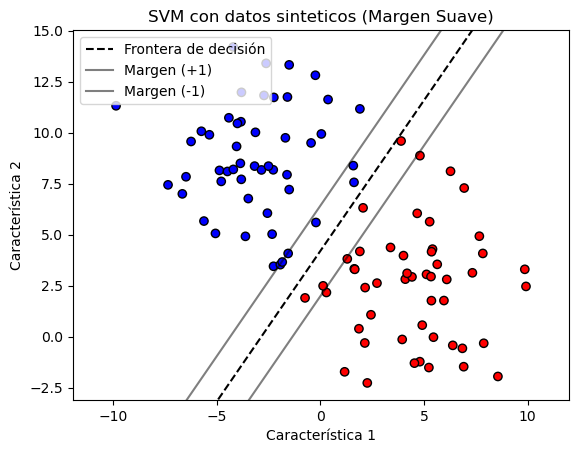

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs



# 1. GENERAR DATOS MÁS MEZCLADOS
# Aumentamos cluster_std de 1.2 a 2.8 para crear superposición
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.8)

# 2. Entrenar modelo
modelo = SVMLinealFundamental(learning_rate=0.001, lambda_param=0.05, n_iters=2000)
modelo.fit(X, y)

# 3. Función para graficar
def visualizar_svm(X, y, modelo):
    plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, cmap='bwr', edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)

    def calcular_hiperplano(x, w, b, offset):
        return (b + offset - w[0] * x) / w[1]

    yy_centro = calcular_hiperplano(xx, modelo.w, modelo.b, 0)
    yy_margen_arriba = calcular_hiperplano(xx, modelo.w, modelo.b, 1)
    yy_margen_abajo = calcular_hiperplano(xx, modelo.w, modelo.b, -1)

    plt.plot(xx, yy_centro, 'k--', label='Frontera de decisión')
    plt.plot(xx, yy_margen_arriba, 'k-', alpha=0.5, label='Margen (+1)')
    plt.plot(xx, yy_margen_abajo, 'k-', alpha=0.5, label='Margen (-1)')

    plt.ylim(ylim)
    plt.title('SVM con datos sinteticos (Margen Suave)')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.legend()
    plt.show()

visualizar_svm(X, y, modelo)

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Cargar el dataset de vinos desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# 2. Preparar el problema: Clasificación binaria (Calidad >= 7 es 'Alta Calidad' = 1, sino 0)
X = wine_data.drop('quality', axis=1)
y = (wine_data['quality'] >= 7).astype(int)

# 3. Dividir en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalar los datos (¡Obligatorio para SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instanciamos nuestra clase creada desde cero
modelo_fundamental = SVMLinealFundamental(learning_rate=0.001, lambda_param=0.01, n_iters=1000)

# Entrenamos usando los datos escalados (el descenso de gradiente es muy sensible a la escala)
# Nota: Asumimos que X_train_scaled y y_train ya existen del paso de preparación
modelo_fundamental.fit(X_train_scaled, y_train.values)

# Realizamos las predicciones
predicciones_fundamentales = modelo_fundamental.predict(X_test_scaled)

# Evaluamos la precisión manualmente
precision_fundamental = np.mean(predicciones_fundamentales == y_test.values)
print(f"Precisión de la SVM Fundamental (desde cero): {precision_fundamental * 100:.2f}%")

Precisión de la SVM Fundamental (desde cero): 85.31%


### Enfoque Moderno (Scikit-Learn con Datos Reales)
En la práctica profesional, delegamos la optimización matemática a rutinas súper eficientes (como LIBSVM) a través de scikit-learn.

Nota crucial: Las SVM son extremadamente sensibles a la escala de los datos porque se basan en el cálculo de distancias. Siempre debemos estandarizar los datos (StandardScaler) antes de entrenar.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Cargar datos y preparar problema
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

X = wine_data.drop('quality', axis=1)
y = (wine_data['quality'] >= 7).astype(int)

# 2. Dividir datos (único paso fuera del pipeline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Construir el Pipeline Profesional
# El Pipeline encadena el escalado y el estimador final
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', C=1.0))
])

# 4. Entrenar (El pipeline ajusta el scaler solo en X_train y luego entrena el SVC)
svm_pipeline.fit(X_train, y_train)

# 5. Evaluar (El pipeline escala automáticamente X_test con los parámetros aprendidos)
predicciones_pipe = svm_pipeline.predict(X_test)
precision_pipe = accuracy_score(y_test, predicciones_pipe)

print(f"Precisión del Pipeline SVC Lineal: {precision_pipe * 100:.2f}%")

# Extraer información del modelo interno si es necesario:
modelo_interno = svm_pipeline.named_steps['svc']
print(f"Número de Vectores de Soporte: {sum(modelo_interno.n_support_)}")

Precisión del Pipeline SVC Lineal: 85.31%
Número de Vectores de Soporte: 382


## Clasificación No Lineal y el 'Kernel Trick'

### Las Limitaciones de la Linealidad y la Función $\phi(\mathbf{x})$

Imagina un conjunto de datos donde la clase positiva está agrupada en el centro (como una diana) y la clase negativa forma un anillo alrededor. Ninguna línea recta en ese plano 2D podrá separar ambas clases. A esto se le conoce como el problema de separación concéntrica (o de forma más simple en lógica binaria, el problema XOR).

* ***La solución geométrica***: Si no puedes separarlos en 2D, llévalos a 3D. Podemos aplicar una función de transformación espacial $\phi(\mathbf{x})$ que añada nuevas dimensiones basadas en combinaciones de las existentes. Por ejemplo, si tenemos $\mathbf{x} = (x_1, x_2)$, podríamos mapearlo a un espacio tridimensional:
$$\phi(\mathbf{x}) = (x_1, x_2, x_1^2 + x_2^2)$$

Al elevar los datos en el eje Z (basado en su distancia al origen), las clases quedan a diferentes "alturas", permitiendo que un hiperplano plano en 3D las corte limpiamente.

Para demostrar cómo una SVM "dobla" el espacio, vamos a generar un dataset clásico que es imposible de separar con una línea recta: círculos concéntricos. Luego, aplicaremos la función matemática $\phi(\mathbf{x})$ elevando los puntos en un nuevo eje $Z$, calculado como $z = x_1^2 + x_2^2$.

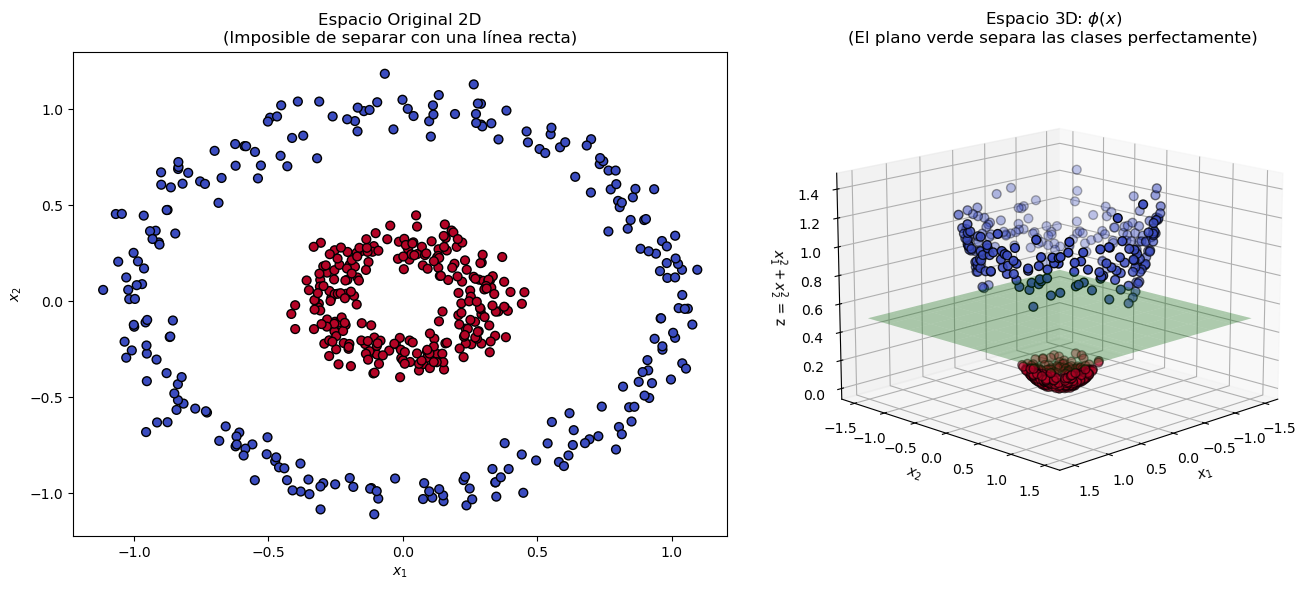

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# 1. Generar datos no lineales (círculos concéntricos)
# factor=0.3 crea un círculo interno pequeño, noise añade realismo
X, y = make_circles(n_samples=500, factor=0.3, noise=0.06, random_state=42)
x1 = X[:, 0]
x2 = X[:, 1]

# 2. El Mapeo a 3D (Aplicando la función para el eje Z)
# Elevamos los puntos basándonos en su distancia al origen
z = x1**2 + x2**2

# 3. Graficar la transformación
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Espacio Original 2D
ax1 = fig.add_subplot(121)
ax1.scatter(x1, x2, c=y, cmap='coolwarm', edgecolors='k', s=40)
ax1.set_title('Espacio Original 2D\n(Imposible de separar con una línea recta)')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')

# Subplot 2: Espacio Transformado 3D
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(x1, x2, z, c=y, cmap='coolwarm', edgecolors='k', s=40)

# Dibujar un hiperplano separador plano en 3D (Z = 0.5)
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
zz = np.full(xx.shape, 0.5)
ax2.plot_surface(xx, yy, zz, alpha=0.3, color='green')

ax2.set_title('Espacio 3D: $\phi(x)$\n(El plano verde separa las clases perfectamente)')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_zlabel('$x_1^2 + x_2^2$ = z')

# Ajustar ángulo de cámara para mejor visualización
ax2.view_init(elev=15, azim=45)

plt.tight_layout()
plt.show()

### El Teorema de Mercer y el Truco del Kernel
Llevar datos a 3D es fácil. Pero, ***¿y si para separar los datos necesitamos proyectarlos a un espacio de 10,000 dimensiones o a un espacio de dimensiones infinitas?*** 

El costo computacional de calcular $\phi(\mathbf{x})$ para cada punto nos dejaría sin memoria instantáneamente. Aquí entra la matemática de Vladimir Vapnik (co-inventor de las SVM). Si observamos el problema de optimización dual de las SVM (cómo el algoritmo aprende), notaremos que los datos de entrada $\mathbf{x}$ solo aparecen en forma de producto punto entre pares de muestras: 

$$\mathbf{x}_i \cdot \mathbf{x}_j$$

El Kernel Trick se basa en el Teorema de Mercer, el cual nos dice que en lugar de mapear los datos al espacio complejo y luego calcular su producto punto, podemos usar una Función Kernel $K$ que calcule ese producto punto directamente en el espacio original:
$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

¡Esto significa que podemos operar en espacios de infinitas dimensiones sin tener que calcular o visitar esas dimensiones jamás!

### Tipos de Kernels Principales

* ***Polinomial***: Dobla el espacio usando grados polinómicos. Bueno para procesamiento de imágenes.
$$K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma (\mathbf{x}_i \cdot \mathbf{x}_j) + r)^d$$

* ***RBF (Radial Basis Function o Gaussiano)***: Es el Kernel por defecto en ML. Mapea los datos a un espacio de infinitas dimensiones. Calcula la "similitud" o cercanía entre dos puntos. Donde, el hiperparámetro $\gamma$ (Gamma): Define qué tan lejos llega la influencia de un solo punto de entrenamiento.

    * $\gamma$ alto: Influencia muy local (fronteras de decisión muy ajustadas, riesgo de overfitting).
    * $\gamma$ bajo: Influencia amplia (fronteras suaves, riesgo de underfitting).


$$ K( \mathbf{x}_i, \mathbf{x}_j) = \exp(- \gamma | \mathbf{x}_i - \mathbf{x}_j |^2 ) $$



### Enfoque Fundamental (Entendiendo el Kernel RBF)
Para desmitificar el Kernel RBF, vamos a programar exactamente la función matemática que evalúa la similitud entre dos vectores (que podrían representar dos vinos en nuestro dataset).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
import ipywidgets as widgets
from IPython.display import display

def plot_svm_interactivo(dataset, kernel, C, gamma, degree):
    # 1. Generar los datos sintéticos elegidos
    if dataset == 'Lunas Entrelazadas':
        X, y = datasets.make_moons(n_samples=200, noise=0.15, random_state=42)
    else: 
        X, y = datasets.make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)
        
    # 2. Entrenar el modelo SVM con los parámetros de la interfaz
    modelo = SVC(kernel=kernel, C=C, gamma=gamma, degree=degree)
    modelo.fit(X, y)

    # 3. Crear una malla de puntos para pintar la frontera de decisión
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 4. Configurar el gráfico
    plt.figure(figsize=(10, 6))
    
    # Pintar las regiones de decisión (el fondo)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # Pintar los puntos de datos reales
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40)

    # 5. Resaltar los Vectores de Soporte (círculos vacíos alrededor del punto)
    plt.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1], 
                s=150, linewidth=1.5, facecolors='none', edgecolors='black', 
                label='Vectores de Soporte')

    # Añadir métricas al título
    precision = modelo.score(X, y)
    plt.title(f"Kernel: {kernel.upper()} | C: {C:.2f} | Precisión: {precision*100:.1f}% | N° Vectores: {len(modelo.support_vectors_)}", fontsize=14)
    plt.legend()
    plt.show()

# 6. Conectar la función a los controles interactivos (ipywidgets)
widgets.interact(plot_svm_interactivo,
    dataset=widgets.Dropdown(options=['Lunas Entrelazadas', 'Linealmente Separables'], description='Datos:'),
    kernel=widgets.Dropdown(options=['linear', 'poly', 'rbf'], value='rbf', description='Kernel:'),
    C=widgets.FloatLogSlider(value=1.0, base=10, min=-1, max=3, step=0.2, description='C (Margen):'),
    gamma=widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.2, description='Gamma (RBF):'),
    degree=widgets.IntSlider(value=3, min=2, max=5, description='Grado (Poly):')
);

interactive(children=(Dropdown(description='Datos:', options=('Lunas Entrelazadas', 'Linealmente Separables'),…

In [7]:
import numpy as np

def rbf_kernel_manual(x1, x2, gamma=0.1):
    """
    Calcula el producto punto en dimensión infinita entre x1 y x2
    usando la función de Base Radial Gaussiana.
    """
    # 1. Distancia Euclidiana al cuadrado entre ambos vectores
    distancia_cuadrada = np.linalg.norm(x1 - x2) ** 2
    
    # 2. Aplicar la función exponencial negativa escalada por Gamma
    similitud = np.exp(-gamma * distancia_cuadrada)
    
    return similitud

# Simulemos dos vinos con 3 características químicas: [Alcohol, pH, Sulfatos]
vino_A = np.array([12.5, 3.2, 0.6])
vino_B = np.array([12.4, 3.3, 0.5])
vino_C = np.array([9.0, 2.8, 1.2]) # Muy distinto

print(f"Similitud A y B: {rbf_kernel_manual(vino_A, vino_B, gamma=1.0):.4f}") 
print(f"Similitud A y C: {rbf_kernel_manual(vino_A, vino_C, gamma=1.0):.4f}") 
# Resultados esperados: A y B tendrán un valor cercano a 1 (muy similares).
# A y C tendrán un valor cercano a 0 (muy distintos).

Similitud A y B: 0.9704
Similitud A y C: 0.0000


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Asumimos que X_train, X_test, y_train, y_test provienen del Módulo 1
# (Clasificación de vinos: 1 = Alta calidad, 0 = Baja calidad)

# Construimos el Pipeline con Kernel RBF
svm_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale')) 
    # gamma='scale' es el default inteligente de sklearn: 1 / (n_features * X.var())
])

# Entrenamos el modelo
svm_rbf_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [9]:
# Evaluamos
predicciones_rbf = svm_rbf_pipeline.predict(X_test)
precision_rbf = accuracy_score(y_test, predicciones_rbf)

print(f"Precisión del Pipeline SVC RBF (No Lineal): {precision_rbf * 100:.2f}%")
# En la práctica, con este dataset, notarás que el Kernel RBF
# suele otorgar un incremento porcentual interesante sobre el modelo lineal
# al capturar las interacciones complejas (ej. alta acidez solo es buena si hay suficiente azúcar).

Precisión del Pipeline SVC RBF (No Lineal): 87.50%


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar y preparar los datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

X = wine_data.drop('quality', axis=1)
# Clasificación binaria: 1 para Alta Calidad (>=7), 0 para Baja Calidad
y = (wine_data['quality'] >= 7).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pipeline con Kernel Polinomial (Grado 3 por defecto)
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='poly', degree=3, C=1.0, coef0=1.0)) 
    # coef0 ayuda a regular cómo los términos de alto grado afectan el modelo
])

# 3. Pipeline con Kernel RBF (Gaussiano)
rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# 4. Entrenamiento y Predicción
poly_pipeline.fit(X_train, y_train)
rbf_pipeline.fit(X_train, y_train)

pred_poly = poly_pipeline.predict(X_test)
pred_rbf = rbf_pipeline.predict(X_test)

# 5. Comparación de Resultados
print("--- RESULTADOS EN DATASET DE VINOS ---")
print(f"Precisión Kernel Polinomial: {accuracy_score(y_test, pred_poly) * 100:.2f}%")
print(f"Precisión Kernel RBF:        {accuracy_score(y_test, pred_rbf) * 100:.2f}%")


--- RESULTADOS EN DATASET DE VINOS ---
Precisión Kernel Polinomial: 86.56%
Precisión Kernel RBF:        87.50%


#### ¿ Porque el kernel RBF funciona mejor?

El RBF es más flexible. El Kernel polinomial puede volverse inestable (sus valores tienden a cero o a infinito rápidamente) si las características no están perfectamente calibradas, y suele requerir más ajuste de hiperparámetros (grado, coef0). RBF asume que muestras con química similar tendrán una calidad similar, lo cual funciona excelente aquí.

# Support Vector Regression (SVR)

## De clasificar a predecir
En clasificación (SVC), buscábamos un hiperplano que separara las clases con el margen más amplio posible, y penalizábamos los puntos que caían dentro del margen.

En regresión (SVR), la lógica se invierte: buscamos un hiperplano (una línea o superficie de regresión) que se ajuste a los datos, creando un tubo de tolerancia alrededor de esta línea. Queremos que la mayor cantidad de puntos caigan dentro de este tubo, y penalizamos los puntos que caen fuera de él.

## El Tubo $\epsilon$-Insensible (Épsilon)

Este tubo se define mediante un nuevo hiperparámetro llamado $\epsilon$ (Épsilon).Cualquier predicción que caiga dentro del rango $[y_i - \epsilon, \ y_i + \epsilon]$ se considera perfecta; el error se evalúa como cero. 

Esto se conoce como la función de pérdida $\epsilon$-insensible.Solo los puntos que escapan del tubo contribuyen al error y esos puntos fuera del tubo (o justo en su límite) son los que se convierten en los Vectores de Soporte en SVR.

Matemáticamente, nuestro objetivo de optimización cambia a:
$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$

Sujeto a las restricciones de que las predicciones no se desvíen del valor real por más de $\epsilon$, más una holgura permitida:
$$y_i - (\mathbf{w} \cdot \mathbf{x}_i + b) \le \epsilon + \xi_i$$

$$(\mathbf{w} \cdot \mathbf{x}_i + b) - y_i \le \epsilon + \xi_i^*$$

Donde:

* $\epsilon$ dicta el ancho del tubo (nuestra tolerancia al error).

* $\xi_i, \xi_i^*$ son las variables de holgura para excesos por encima o por debajo del tubo.

* $C$ controla cuánto penalizamos a los puntos que escapan del tubo.

Interactúa con el siguiente simulador para visualizar cómo $\epsilon$ y $C$ moldean la regresión. Observa cómo al ensanchar el tubo ($\epsilon$ mayor), menos puntos quedan fuera, reduciendo el número de vectores de soporte y simplificando el modelo.


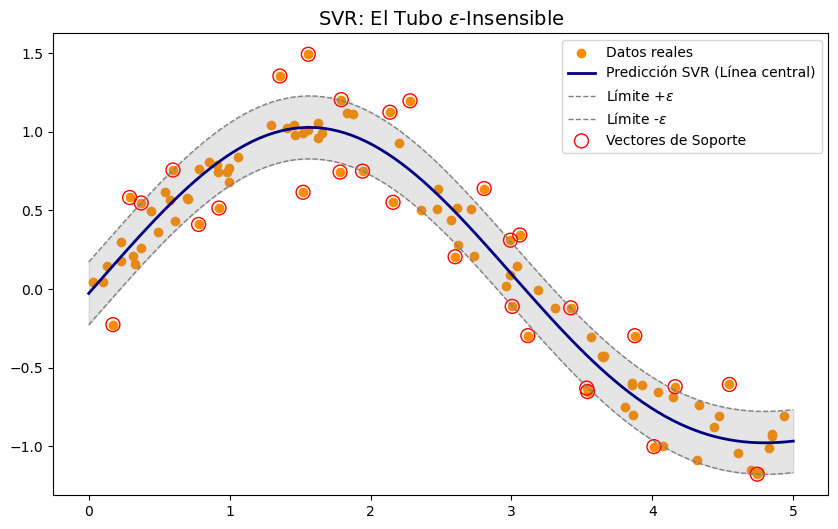

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# 1. Generar datos de regresión no lineales (onda senoidal con ruido)
np.random.seed(42)
X_ondas = np.sort(5 * np.random.rand(100, 1), axis=0)
y_ondas = np.sin(X_ondas).ravel() + np.random.normal(0, 0.2, X_ondas.shape[0])

# 2. Entrenar el modelo SVR con Kernel RBF
# Epsilon de 0.2 significa que errores menores a 0.2 no se penalizan
modelo_svr_visual = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.2)
modelo_svr_visual.fit(X_ondas, y_ondas)

# 3. Predicciones y límites del tubo
X_test_ondas = np.linspace(0, 5, 100)[:, np.newaxis]
y_pred_ondas = modelo_svr_visual.predict(X_test_ondas)
y_pred_superior = y_pred_ondas + modelo_svr_visual.epsilon
y_pred_inferior = y_pred_ondas - modelo_svr_visual.epsilon

# 4. Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_ondas, y_ondas, color='darkorange', label='Datos reales')
plt.plot(X_test_ondas, y_pred_ondas, color='navy', lw=2, label='Predicción SVR (Línea central)')

# Dibujar el tubo Epsilon
plt.plot(X_test_ondas, y_pred_superior, color='gray', lw=1, linestyle='--', label='Límite +$\epsilon$')
plt.plot(X_test_ondas, y_pred_inferior, color='gray', lw=1, linestyle='--', label='Límite -$\epsilon$')
plt.fill_between(X_test_ondas.ravel(), y_pred_inferior, y_pred_superior, color='gray', alpha=0.2)

# Resaltar Vectores de Soporte (Puntos fuera o en el borde del tubo)
plt.scatter(X_ondas[modelo_svr_visual.support_], y_ondas[modelo_svr_visual.support_], 
            s=100, facecolors='none', edgecolors='red', label='Vectores de Soporte')

plt.title('SVR: El Tubo $\epsilon$-Insensible', fontsize=14)
plt.legend()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import ipywidgets as widgets
from IPython.display import display

# 1. Generar datos no lineales (onda senoidal con ruido)
np.random.seed(42)
X_ondas = np.sort(5 * np.random.rand(100, 1), axis=0)
y_ondas = np.sin(X_ondas).ravel() + np.random.normal(0, 0.2, X_ondas.shape[0])

def plot_svr_interactivo(epsilon, C, kernel):
    # 2. Entrenar el modelo SVR con los parámetros de la interfaz
    modelo = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma='scale')
    modelo.fit(X_ondas, y_ondas)

    # 3. Preparar datos para la línea de predicción suave
    X_plot = np.linspace(0, 5, 100)[:, np.newaxis]
    y_pred = modelo.predict(X_plot)
    y_pred_sup = y_pred + modelo.epsilon
    y_pred_inf = y_pred - modelo.epsilon

    # 4. Configurar el gráfico
    plt.figure(figsize=(10, 6))
    
    # Dibujar el tubo Epsilon (sombreado gris)
    plt.fill_between(X_plot.ravel(), y_pred_inf, y_pred_sup, color='gray', alpha=0.2, label='Tubo $\epsilon$')
    
    # Líneas de los márgenes
    plt.plot(X_plot, y_pred_sup, color='gray', lw=1, linestyle='--')
    plt.plot(X_plot, y_pred_inf, color='gray', lw=1, linestyle='--')

    # Línea central de predicción
    plt.plot(X_plot, y_pred, color='navy', lw=2, label='Predicción SVR')

    # Puntos de datos reales
    plt.scatter(X_ondas, y_ondas, color='darkorange', label='Datos reales', s=30)

    # Resaltar los Vectores de Soporte (puntos fuera o en el borde del tubo)
    plt.scatter(X_ondas[modelo.support_], y_ondas[modelo.support_], 
                s=100, linewidth=1.5, facecolors='none', edgecolors='red', 
                label='Vectores de Soporte')

    plt.title(f"SVR | Kernel: {kernel.upper()} | $\epsilon$: {epsilon:.2f} | C: {C:.1f} | N° Vectores: {len(modelo.support_)}", fontsize=14)
    plt.ylim(-2, 2) # Fijar ejes para evitar saltos bruscos en la animación
    plt.legend(loc='upper right')
    plt.show()

# 5. Conectar la función a los controles interactivos
widgets.interact(plot_svr_interactivo,
    epsilon=widgets.FloatSlider(value=0.2, min=0.0, max=1.5, step=0.05, description='Epsilon ($\epsilon$):'),
    C=widgets.FloatLogSlider(value=10.0, base=10, min=-1, max=3, step=0.5, description='C (Penalidad):'),
    kernel=widgets.Dropdown(options=['linear', 'poly', 'rbf'], value='rbf', description='Kernel:')
);

interactive(children=(FloatSlider(value=0.2, description='Epsilon ($\\epsilon$):', max=1.5, step=0.05), FloatL…

# Prediciendo el Nivel de Alcohol en Vinos

Ahora aplicaremos este paradigma a nuestro dataset estructurado. En lugar de predecir la clase de calidad, usaremos las variables químicas (pH, acidez, densidad, etc.) para realizar una regresión y predecir exactamente el alcohol (% vol).

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# 2. Reestructurar el problema para Regresión
# Ahora 'alcohol' es nuestro objetivo continuo (y), y el resto son las características (X)
X_reg = wine_data.drop('alcohol', axis=1)
y_reg = wine_data['alcohol']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Construir el Pipeline para SVR
# Usaremos RBF porque las relaciones químicas rara vez son estrictamente lineales
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1)) 
])

# 4. Entrenar
svr_pipeline.fit(X_train_reg, y_train_reg)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [14]:

# 5. Predicciones
predicciones_alcohol = svr_pipeline.predict(X_test_reg)

# 6. Evaluación Inicial (Profundizaremos en el Módulo 4)
mae = mean_absolute_error(y_test_reg, predicciones_alcohol)
r2 = r2_score(y_test_reg, predicciones_alcohol)

print("--- RESULTADOS SVR: PREDICCIÓN DE ALCOHOL ---")
print(f"Error Absoluto Medio (MAE): {mae:.3f} grados de alcohol")
print(f"R^2 Score: {r2:.3f}")
print(f"Porcentaje de datos que son Vectores de Soporte: {(len(svr_pipeline.named_steps['svr'].support_) / len(X_train_reg)) * 100:.1f}%")

--- RESULTADOS SVR: PREDICCIÓN DE ALCOHOL ---
Error Absoluto Medio (MAE): 0.361 grados de alcohol
R^2 Score: 0.808
Porcentaje de datos que son Vectores de Soporte: 79.7%


# Evaluación de Modelos (Clasificación vs. Regresión)

## evaluación de modelos de clasificación

Cuando usamos nuestro SVC para predecir si un vino es de ***"Alta Calidad"*** o ***"Baja Calidad"***, la métrica más intuitiva es la Precisión (Accuracy): el porcentaje total de aciertos. Sin embargo, el Accuracy puede ser engañoso si las clases están desbalanceadas (por ejemplo, si el 90% de los vinos son malos, un modelo que siempre diga "Malo" tendrá 90% de Accuracy sin haber aprendido nada).

Por eso, recurrimos a la Matriz de Confusión, que desglosa nuestras predicciones en cuatro cuadrantes:

* ***Verdaderos Positivos (TP)***: Vino de alta calidad predicho correctamente.

* ***Verdaderos Negativos (TN)***: Vino de baja calidad predicho correctamente.

* ***Falsos Positivos (FP)***: Vino de baja calidad que el modelo etiquetó como de alta calidad (Error Tipo I).

* ***Falsos Negativos (FN)***: Vino de alta calidad que el modelo etiquetó como de baja calidad (Error Tipo II).

De esta matriz se derivan tres métricas cruciales:

* ***Precision***: "De todos los vinos que el modelo dijo que eran buenos, ¿cuántos lo eran realmente?"
$$Precision = \frac{TP}{TP + FP}$$

* ***Recall (Sensibilidad)***: "De todos los vinos que realmente son buenos, ¿cuántos logró encontrar el modelo?"
$$Recall = \frac{TP}{TP + FN}$$

* ***F1-Score***: La media armónica entre Precision y Recall. Es ideal cuando buscas un balance entre ambas o tienes clases desbalanceadas.
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

## Curvas ROC y AUC en SVM
Hasta ahora evaluamos el modelo basándonos en si la predicción final era 1 o 0 (Alta o Baja calidad). Pero internamente, la SVM no escupe ceros y unos mágicamente. Lo que la SVM calcula realmente es la distancia de cada punto al hiperplano separador (lo que en Scikit-Learn se llama decision_function).Si la distancia es positiva, predice 1; si es negativa, predice 0. Ese es el umbral por defecto (umbral = 0). Pero, ¿qué pasa si cambiamos ese umbral? ¿Qué pasa si exigimos que el vino esté muy lejos del hiperplano para clasificarlo como "Alta Calidad"?

Aquí entra la Curva ROC (Receiver Operating Characteristic), que nos permite visualizar el rendimiento de nuestro modelo en todos los umbrales de clasificación posibles, graficando dos métricas enfrentadas:

* ***Eje Y - Tasa de Verdaderos Positivos (TPR o Recall)***: $TPR = \frac{TP}{TP + FN}$. De todos los vinos buenos, ¿qué porcentaje atrapamos? Queremos que sea 1.0.

* ***Eje X - Tasa de Falsos Positivos (FPR)***: $FPR = \frac{FP}{FP + TN}$. De todos los vinos malos, ¿qué porcentaje clasificamos erróneamente como buenos? Queremos que sea 0.0.

El AUC (Área Bajo la Curva) resume esta gráfica en un solo número:

* ***AUC = 1.0***: Modelo perfecto (separa las clases sin errores).
* ***AUC = 0.5***: Modelo inútil (equivale a lanzar una moneda al aire).

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# === A. EVALUACIÓN DE CLASIFICACIÓN (Calidad del Vino) ===
X_cls = wine_data.drop('quality', axis=1)
y_cls = (wine_data['quality'] >= 7).astype(int)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
modelo_svc = SVC(kernel='rbf', C=1.0)
modelo_svc.fit(scaler_c.fit_transform(X_train_c), y_train_c)
pred_c = modelo_svc.predict(scaler_c.transform(X_test_c))

print("=== REPORTE DE CLASIFICACIÓN (SVC) ===")
print("Matriz de Confusión:\n", confusion_matrix(y_test_c, pred_c))
print("\nMétricas Detalladas:\n", classification_report(y_test_c, pred_c))

=== REPORTE DE CLASIFICACIÓN (SVC) ===
Matriz de Confusión:
 [[268   5]
 [ 35  12]]

Métricas Detalladas:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       273
           1       0.71      0.26      0.38        47

    accuracy                           0.88       320
   macro avg       0.80      0.62      0.65       320
weighted avg       0.86      0.88      0.85       320



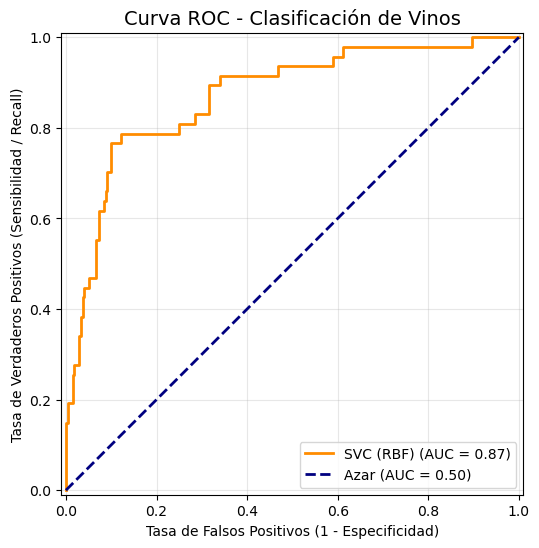

El Área Bajo la Curva (AUC) es: 0.872


In [16]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 1. Entrenar modelo
modelo_svc_roc = SVC(kernel='rbf', C=1.0)
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)
modelo_svc_roc.fit(X_train_scaled, y_train_c)

# 2. Scores para ROC
y_scores = modelo_svc_roc.decision_function(X_test_scaled)

# 3. Validación para evitar warning si solo hay una clase en test
if y_test_c.nunique() < 2:
    print("No se puede calcular ROC: y_test_c contiene una sola clase.")
else:
    fpr, tpr, umbrales = roc_curve(y_test_c, y_scores)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(8, 6))
    roc_display = RocCurveDisplay(
        fpr=fpr,
        tpr=tpr,
        roc_auc=roc_auc,
        name='SVC (RBF)'  # antes: estimator_name
    )
    roc_display.plot(
        ax=ax,
        curve_kwargs={'color': 'darkorange', 'lw': 2}  # antes: color=..., lw=...
    )

    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')
    ax.set_title('Curva ROC - Clasificación de Vinos', fontsize=14)
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.show()

    print(f"El Área Bajo la Curva (AUC) es: {roc_auc:.3f}")


## Evaluación en Regresión (SVR)

Cuando usamos nuestro SVR para predecir el % exacto de Alcohol, no existen los "aciertos absolutos". Si el alcohol real es 12.5% y predecimos 12.4%, ¿es un acierto o un error? En regresión, medimos la distancia entre la predicción y la realidad, a lo que llamamos residuos.Las métricas cambian de lógica:

***MAE (Mean Absolute Error - Error Absoluto Medio)***: 

Es la diferencia promedio entre nuestras predicciones y los valores reales. Se expresa en la misma unidad que el problema.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Ej: Un MAE de 0.5 significa que, en promedio, nos equivocamos por medio grado de alcohol.

***RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio)***: 

Al elevar el error al cuadrado antes de promediarlo, penaliza muy fuertemente los errores grandes.
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

***Coeficiente de Determinación ($R^2$)***: 

Va de 0 a 1 (o puede ser negativo si el modelo es pésimo). Indica qué porcentaje de la variabilidad del alcohol es explicado por nuestro modelo. Un $R^2$ de 1.0 es una predicción perfecta. $R^2$ es una métrica de comparación entre dos modelos: nuestro modelo predictivo contra un modelo que predece siempre la media.
 $$R^2 = 1 - \frac{SSR}{SST}$$

 Donde, SST (Suma Total de Cuadrados) representa la varianza total de los datos. Físicamente, es el error que cometeríamos si no tuviéramos ningún algoritmo de Machine Learning y simplemente decidiéramos predecir siempre el promedio ($\bar{y}$) para todos los vinos.
    $$SST = \sum_{i=1}^{n} (y_i - \bar{y})^2$$

 Y SSR (Suma de Cuadrados de los Residuos), representa el error que comete nuestro modelo. Es la suma de las distancias al cuadrado entre los valores reales y las predicciones de nuestra SVM.
    $$SSR = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

 ***¿Por qué el máximo es 1.0?***

 Si tu modelo es absolutamente perfecto, no comete errores. Por lo tanto, $y_i = \hat{y}_i$ en todos los casos. Esto hace que el numerador $SSR = 0$.Al aplicar la fórmula: $R^2 = 1 - \frac{0}{SST} = 1 - 0 = 1$.

 ***¿Qué ocurre si es 0.0?***

 Si tu modelo es tan malo que sus predicciones generan el mismo error que simplemente predecir la media, entonces $SSR = SST$.Al aplicar la fórmula: $R^2 = 1 - \frac{SST}{SST} = 1 - 1 = 0$.

 ***¿Puede ser negativo (y qué significa cuando lo es)?***

 En modelos no lineales (como SVR con Kernel RBF) o modelos sin término de sesgo, las predicciones pueden ser catastróficas. Si tu algoritmo hace predicciones peores que simplemente adivinar el promedio de los datos, entonces el error de tu modelo supera la varianza total ($SSR > SST$).Matemáticamente, la fracción $\frac{SSR}{SST}$ se vuelve mayor a 1.Ejemplo: $1 - 1.5 = -0.5$.Un $R^2$ negativo es la prueba matemática de que tu modelo está empeorando las cosas.

In [17]:
# === B. EVALUACIÓN DE REGRESIÓN (Nivel de Alcohol) ===
X_reg = wine_data.drop('alcohol', axis=1)
y_reg = wine_data['alcohol']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
modelo_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
modelo_svr.fit(scaler_r.fit_transform(X_train_r), y_train_r)
pred_r = modelo_svr.predict(scaler_r.transform(X_test_r))

print("\n=== REPORTE DE REGRESIÓN (SVR) ===")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test_r, pred_r):.3f} % vol")
print(f"RMSE (Raíz Error Cuadrático): {np.sqrt(mean_squared_error(y_test_r, pred_r)):.3f} % vol")
print(f"R^2 (Coeficiente Determinación): {r2_score(y_test_r, pred_r):.3f}")


=== REPORTE DE REGRESIÓN (SVR) ===
MAE (Error Absoluto Medio): 0.361 % vol
RMSE (Raíz Error Cuadrático): 0.489 % vol
R^2 (Coeficiente Determinación): 0.808


Además de los promedios básicos, necesitamos medir la robustez y el valor de negocio de la regresión:

***Error Absoluto Mediano (MedAE)***: 

Mientras que el MAE y el RMSE son arrastrados por los outliers (valores atípicos), el MedAE utiliza la mediana. Esto nos dice cuál es nuestro error "típico" ignorando por completo aquellas predicciones catastróficas aisladas. En algoritmos sensibles a distancias como SVR, esta métrica es vital.

Esta métrica se basa en el concepto estadístico de Punto de Ruptura (Breakdown Point).El MedAE se define como la mediana del conjunto de todos los errores absolutos:
$$MedAE = \text{mediana}(|y_1 - \hat{y}_1|, |y_2 - \hat{y}_2|, \dots, |y_n - \hat{y}_n|)$$

El problema del MAE (y RMSE): Tienen un punto de ruptura del $0\%$. Esto significa que basta con que una sola predicción sea infinitamente mala (un error de $\infty$) para que el MAE entero se vuelva $\infty$, destruyendo la métrica por completo. La superioridad del MedAE: Tiene un punto de ruptura del $50\%$. Matemáticamente, hasta que el $50\%$ de tus predicciones no sean completamente erróneas o atípicas, el MedAE se mantendrá estable. El MedAE te dice el error del "centro de masa" de tu modelo.

***Error Porcentual Absoluto Medio (MAPE)***: 

A los gerentes o stakeholders rara vez les importan los "grados de alcohol" de error; piensan en porcentajes. El MAPE mide el tamaño del error en relación con el valor real.

$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

esta ecuación esconde dos problemas críticos:

1. Indefinición por División por Cero: Si el valor real $y_i = 0$, la ecuación lanza una división por cero ($\frac{x}{0}$). El MAPE tiende a infinito. No puedes usar MAPE si tus datos reales contienen ceros (ej. predecir ventas de un producto que no vendió nada un día).

2. Asimetría Estructural (Penaliza más la sobreestimación):El MAPE no es simétrico respecto al error.
    * Caso A (Subestimación): El valor real es 100, predices 50. Error = $\left|\frac{100 - 50}{100}\right| = 50\%$.

    * Caso B (Sobreestimación): El valor real es 50, predices 100. Error = $\left|\frac{50 - 100}{50}\right| = 100\%$.El error absoluto es el mismo en ambos casos (50 unidades), pero el MAPE castiga el doble al modelo por sobreestimar. Entrenar un modelo optimizando el MAPE generará un modelo matemáticamente sesgado a predecir siempre a la baja.

***$R^2$ Ajustado***: 

El $R^2$ normal ($1 - \frac{SSR}{SST}$) tiene un problema fundamental, si agregas una variable aleatoria poco predictiva (inuti) a tu modelo, el $SSR$ nunca puede aumentar, en el peor de los casos se queda igual. Por ende, el $R^2$ siempre sube o se estanca, incitándote a meter variables que no aportan nada al modelo.

El $R^2$ Ajustado ($\bar{R}^2$) soluciona esto introduciendo los grados de libertad:

$$\bar{R}^2 = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$

Donde:
1. $n$ = número total de muestras (vinos).

2. $p$ = número de variables predictoras (pH, densidad, alcohol, etc.).

Analicemos la fracción $\frac{n - 1}{n - p - 1}$. A medida que agregas variables inútiles ($p$ crece), el denominador $(n - p - 1)$ se hace más pequeño. Al dividir por un número más pequeño, la fracción completa se vuelve un multiplicador mayor a 1. Este multiplicador magnifica la porción de "error" $(1 - R^2)$ que le restamos a $1$. Por lo tanto, si la nueva variable no mejora casi nada el $R^2$ bruto, el castigo por aumentar $p$ es más fuerte, y el $\bar{R}^2$ disminuye. La única forma de que el $\bar{R}^2$ suba es si la nueva variable aumenta el poder predictivo lo suficiente como para vencer el castigo matemático del denominador.

### Diagnósticos Estadísticos y Visuales

***Gráfico de Predicción vs. Realidad***: Se grafica la predicción ($\hat{y}$) contra el valor real ($y$). Lo ideal es que todos los puntos caigan exactamente sobre la línea diagonal de 45 grados. Sirve para detectar si el modelo subestima o sobreestima sistemáticamente en ciertos rangos.

***Análisis de Residuos (Residuals Plot)***: Esta es la herramienta de diagnóstico más poderosa. Calculamos el residuo de cada predicción ($Residuo = y_i - \hat{y}_i$) y lo graficamos contra el valor predicho. Lo que se busca es: 
1. Homocedasticidad. Queremos ver una nube de puntos completamente aleatoria y estática alrededor del valor cero. Si los residuos forman un embudo (heterocedasticidad) o una curva en forma de U, significa que la varianza del error no es constante o que el modelo lineal no está capturando una relación no lineal oculta (lo que indicaría que elegimos mal el Kernel).

***Gráfico Q-Q (Quantile-Quantile de Residuos)***: Compara la distribución de los errores de tu modelo contra una distribución normal perfecta. Si los puntos se desvían drásticamente de la línea recta en los extremos (las colas), significa que el modelo es incapaz de predecir los valores anómalos o extremos con precisión.

=== DIAGNÓSTICO AVANZADO DE SVR ===
MedAE (Error Mediano): 0.270 % vol
MAPE (Error Porcentual): 3.43 %
R^2 Ajustado: 0.801 (Frente a R^2 normal: 0.808)


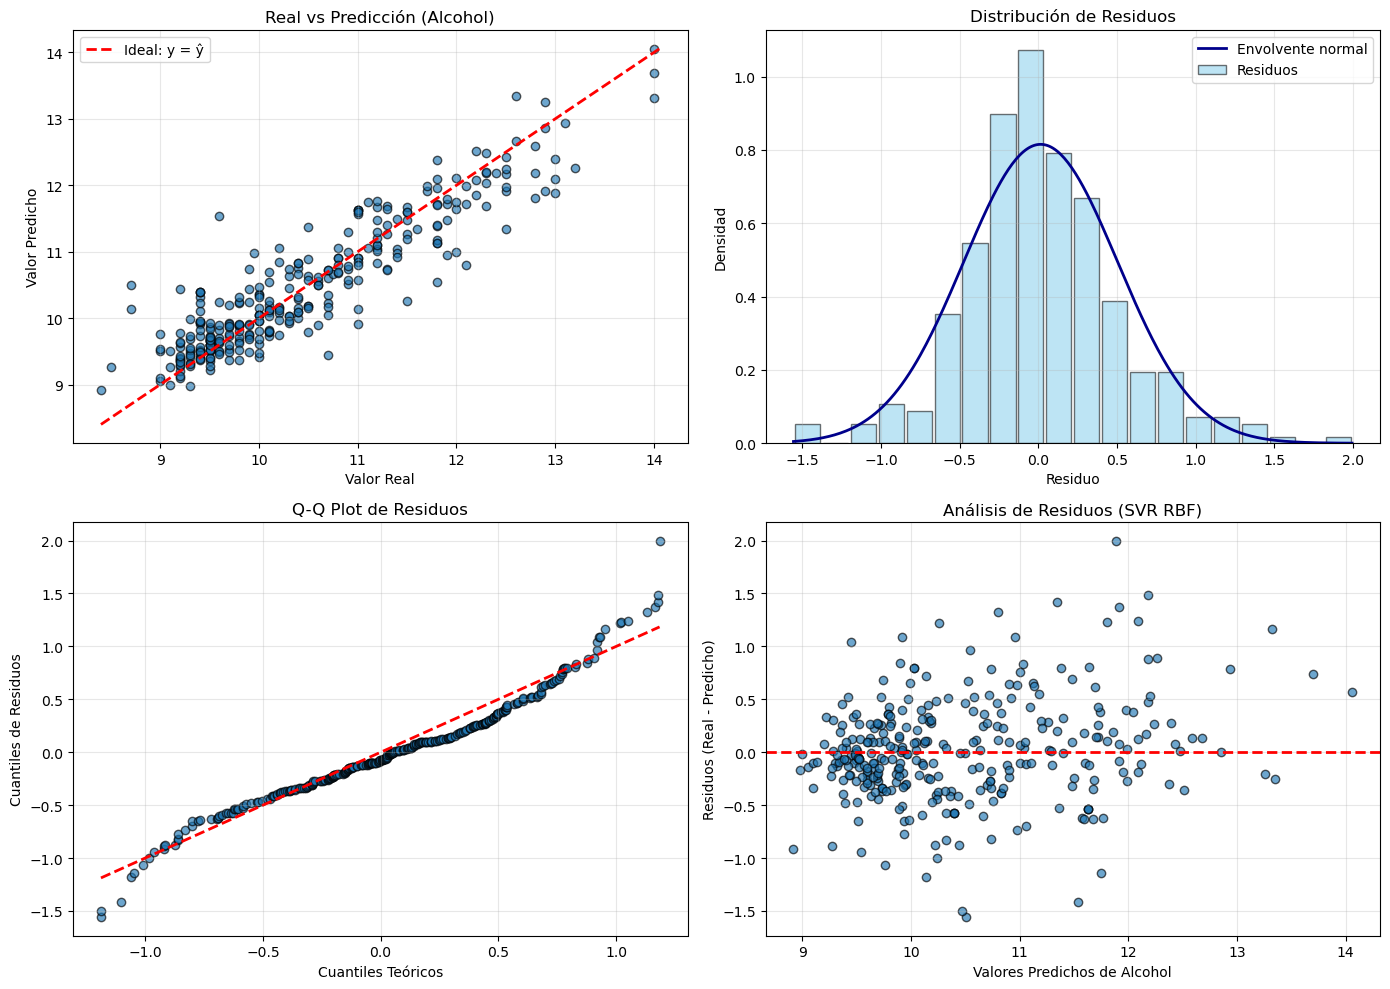

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Asumiendo los datos cargados del Módulo 3
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')
X = wine_data.drop('alcohol', axis=1)
y = wine_data['alcohol']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Entrenar SVR
modelo_svr = SVR(kernel='rbf', C=10, epsilon=0.1)
modelo_svr.fit(X_train_s, y_train)
predicciones = modelo_svr.predict(X_test_s)

# 1. Métricas Avanzadas
n = X_test.shape[0]
p = X_test.shape[1]
r2 = r2_score(y_test, pred_r)
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("=== DIAGNÓSTICO AVANZADO DE SVR ===")
print(f"MedAE (Error Mediano): {median_absolute_error(y_test, pred_r):.3f} % vol")
print(f"MAPE (Error Porcentual): {mean_absolute_percentage_error(y_test, pred_r) * 100:.2f} %")
print(f"R^2 Ajustado: {r2_ajustado:.3f} (Frente a R^2 normal: {r2:.3f})")

# 2. Análisis Visual
residuos = y_test - pred_r

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A) Real vs Predicción (con línea ideal punteada)
ax1 = axes[0, 0]
ax1.scatter(y_test, predicciones, alpha=0.65, edgecolors='k')
min_v = min(y_test.min(), predicciones.min())
max_v = max(y_test.max(), predicciones.max())
ax1.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Ideal: y = ŷ')
ax1.set_title('Real vs Predicción (Alcohol)')
ax1.set_xlabel('Valor Real')
ax1.set_ylabel('Valor Predicho')
ax1.legend()
ax1.grid(alpha=0.3)

# B) Distribución de residuos (barplot + envolvente normal)
ax2 = axes[0, 1]
conteos, bins = np.histogram(residuos, bins=20, density=True)
centros = (bins[:-1] + bins[1:]) / 2
ancho = bins[1] - bins[0]
ax2.bar(centros, conteos, width=ancho * 0.9, alpha=0.55, color='skyblue', edgecolor='k', label='Residuos')

mu, sigma = residuos.mean(), residuos.std(ddof=1)
x_env = np.linspace(residuos.min(), residuos.max(), 300)
envolvente = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_env - mu) / sigma) ** 2)
ax2.plot(x_env, envolvente, 'darkblue', linewidth=2, label='Envolvente normal')
ax2.set_title('Distribución de Residuos')
ax2.set_xlabel('Residuo')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.grid(alpha=0.3)

# C) Gráfica Q-Q de residuos
ax3 = axes[1, 0]
res_ordenados = np.sort(residuos.values if hasattr(residuos, "values") else residuos)
n_res = len(res_ordenados)
q_teoricos = np.sort(np.random.normal(0, 1, n_res))
# Escalamos los cuantiles teóricos a media y std de residuos
q_teoricos = q_teoricos * sigma + mu
ax3.scatter(q_teoricos, res_ordenados, alpha=0.65, edgecolors='k')
ax3.plot([q_teoricos.min(), q_teoricos.max()],
         [q_teoricos.min(), q_teoricos.max()],
         'r--', linewidth=2)
ax3.set_title('Q-Q Plot de Residuos')
ax3.set_xlabel('Cuantiles Teóricos')
ax3.set_ylabel('Cuantiles de Residuos')
ax3.grid(alpha=0.3)

# D) Residuos vs predicción
ax4 = axes[1, 1]
ax4.scatter(predicciones, residuos, alpha=0.65, edgecolors='k')
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_title('Análisis de Residuos (SVR RBF)')
ax4.set_xlabel('Valores Predichos de Alcohol')
ax4.set_ylabel('Residuos (Real - Predicho)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Fuga de Datos (Data Leakage) y el "Overfitting a los Hiperparámetros"

El concepto de Fuga de Datos suele asociarse a incluir por error la variable objetivo dentro de las variables predictoras, pero en la fase de optimización ocurre de una forma más sutil y destructiva.

Cuando ajustas hiperparámetros como $C$ (tolerancia al margen) o $\gamma$ (radio del kernel) observando cómo cambia el rendimiento en tu conjunto $X_{test}$, estás creando un bucle de retroalimentación humana.

* Estás utilizando implícitamente el $X_{test}$ para guiar el aprendizaje de los hiperparámetros.

* El modelo no está "viendo" los datos de prueba durante el entrenamiento matemático, pero tú sí, y estás moldeando la arquitectura del modelo para que encaje perfectamente con ese conjunto de prueba específico.

A este fenómeno se le llama Overfitting al conjunto de validación/prueba. Cuando se despliega un modelo en la vida real y reciba datos genuinamente invisibles, su rendimiento real será dramáticamente inferior al que se reporta. Matemáticamente, has invalidado la premisa fundamental del Machine Learning,  ***el error de prueba es un estimador insesgado del error de generalización***.

## Validación Cruzada de K-Iteraciones (K-Fold Cross-Validation)

Para proteger la "pureza" del conjunto $X_{test}$ (que debe guardarse en una bóveda hasta el último segundo del proyecto), creamos un entorno de pruebas simulado dentro del conjunto de entrenamiento ($X_{train}$).

1. ***Partición Estocástica***: El conjunto $X_{train}$ se divide aleatoriamente en $K$ subconjuntos mutuamente excluyentes (folds). El estándar de la industria suele ser $K=5$ o $K=10$.

2. ***Entrenamiento y Aislamiento***: En la iteración $i$, el algoritmo aísla el pliegue $i$ para que actúe temporalmente como "datos invisibles" (Validación). Entrena desde cero usando la unión de los $K-1$ pliegues restantes.

3. ***Métrica Robusta***: Repite este proceso $K$ veces. La métrica de rendimiento final de esa configuración de hiperparámetros no es el mejor resultado, sino la media aritmética de los $K$ resultados, acompañada de su desviación estándar.

Una desviación estándar alta entre los pliegues indica que el modelo es inestable y muy sensible a la muestra de datos específica, lo cual es una señal de alerta técnica enorme.

## El Espacio de Búsqueda (Grid Search) y la Explosión Combinatoria

La búsqueda en cuadrícula (Grid Search) es una estrategia de optimización por "fuerza bruta" exhaustiva. Es matemáticamente segura porque garantiza encontrar el óptimo global dentro de los límites que le definas, pero tiene un costo computacional masivo.

### La interacción no lineal de hiperparámetros:

No puedes optimizar $C$ aislando $\gamma$, y luego optimizar $\gamma$ aislando $C$. En las Máquinas de Vectores de Soporte (SVM), estos hiperparámetros interactúan de forma compleja:

* Un valor bajo de $\gamma$ (frontera suave) podría requerir un valor alto de $C$ (penalización estricta por errores) para funcionar bien.

* Evaluar cada hiperparámetro por separado te llevaría a un mínimo local subóptimo. Grid Search evalúa el producto cartesiano, analizando el efecto cruzado de todas las variables.

#### El problema de la dimensionalidad computacional:

Por ejemplo, 48 combinaciones con $K=5$ generan 240 entrenamientos de modelo. Sin embargo, en un entorno empresarial podrías querer probar:
* 4 Kernels
* 10 valores de $C$
* 10 valores de $\gamma$
* 5 grados para el kernel polinómico

Esto genera $4 \times 10 \times 10 \times 5 = 2000$ combinaciones. Con $K=10$, tu servidor tendría que entrenar 20,000 modelos completos.

Cuando el espacio de búsqueda se vuelve inmanejable, los ingenieros de Machine Learning abandonan el Grid Search tradicional y recurren a:

* ***Randomized Search***: Prueba combinaciones aleatorias dentro de distribuciones estadísticas. Matemáticamente, está comprobado que suele encontrar un modelo igual de bueno que Grid Search invirtiendo solo una fracción del tiempo computacional.

* ***Optimización Bayesiana***: En lugar de buscar a ciegas, utiliza probabilidad para "recordar" qué combinaciones funcionaron bien en iteraciones anteriores y concentra la búsqueda en las áreas más prometedoras del espacio de hiperparámetros.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Definimos el "Óptimo Real" oculto de nuestro dataset simulado
# Supongamos que el modelo perfecto existe en C=10 y Gamma=0.1
C_optimo = np.log10(10)
gamma_optima = np.log10(0.1)

def rendimiento_simulado(log_C, log_gamma):
    """Simula la precisión de una SVM basándose en la distancia a los hiperparámetros óptimos"""
    distancia = (log_C - C_optimo)**2 + (log_gamma - gamma_optima)**2
    # El accuracy máximo es 95%, y decae exponencialmente al alejarse
    accuracy = 0.95 * np.exp(-0.25 * distancia)
    return accuracy

def plot_grid_search(resolucion):
    # 2. Definir el espacio de búsqueda (Grid)
    # Rango de C: de 10^-2 a 10^3. Rango de Gamma: de 10^-3 a 10^2
    C_range = np.linspace(-2, 3, resolucion)      
    gamma_range = np.linspace(-3, 2, resolucion)  
    
    # 3. Crear la cuadrícula de combinaciones
    CC, GG = np.meshgrid(C_range, gamma_range)
    
    # 4. Calcular el rendimiento para cada punto de la cuadrícula
    Z = rendimiento_simulado(CC, GG)
    
    # 5. Encontrar el ganador (el máximo valor en esta resolución)
    idx_max = np.unravel_index(np.argmax(Z, axis=None), Z.shape)
    mejor_C = C_range[idx_max[1]]
    mejor_gamma = gamma_range[idx_max[0]]
    mejor_acc = Z[idx_max]

    # 6. Graficar el Mapa de Calor (Heatmap)
    plt.figure(figsize=(10, 8))
    # cmap='inferno' va de negro (malo) a amarillo/blanco (excelente)
    cp = plt.pcolormesh(CC, GG, Z, cmap='inferno', shading='auto')
    plt.colorbar(cp, label='Precisión Simulada (Accuracy)')
    
    # Marcar todas las combinaciones que probó el Grid Search
    plt.scatter(CC, GG, color='white', s=10, alpha=0.3, label='Modelos Entrenados')
    
    # Resaltar la estrella ganadora
    plt.scatter([mejor_C], [mejor_gamma], color='cyan', marker='*', s=400, 
                edgecolor='black', linewidth=1.5,
                label=f'Mejor Modelo\nC: $10^{{{mejor_C:.1f}}}$, $\gamma$: $10^{{{mejor_gamma:.1f}}}$\nAcc: {mejor_acc*100:.1f}%')
    
    plt.title(f'Mapa de Calor - Grid Search (Modelos probados: {resolucion * resolucion})', fontsize=14)
    plt.xlabel('Log10(C) - Penalidad por Error (Tolerancia)')
    plt.ylabel('Log10(Gamma) - Radio de Influencia del Kernel')
    
    # Formatear ejes para que muestren la notación científica real
    plt.xticks(np.arange(-2, 4, 1), labels=[f"$10^{{{i}}}$" for i in range(-2, 4)])
    plt.yticks(np.arange(-3, 3, 1), labels=[f"$10^{{{i}}}$" for i in range(-3, 3)])
    
    plt.legend(loc='upper right', framealpha=0.9)
    plt.show()

# 7. Conectar con el control interactivo
widgets.interact(plot_grid_search, 
    resolucion=widgets.IntSlider(value=5, min=3, max=40, step=1, description='Resolución:')
);

interactive(children=(IntSlider(value=5, description='Resolución:', max=40, min=3), Output()), _dom_classes=('…

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import loguniform, uniform

# =====================================================================
# 1. CARGA DE DATOS Y DEFINICIÓN DEL PROBLEMA
# =====================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

X = wine_data.drop('quality', axis=1)
y = (wine_data['quality'] >= 7).astype(int) # Clasificación binaria (Alta vs Baja calidad)

# =====================================================================
# 2. PREVENCIÓN DE FUGA DE DATOS (Data Leakage)
# =====================================================================
# Aislamos el conjunto de prueba ANTES de cualquier transformación.
# Se guarda en una "bóveda" y no se toca hasta la línea final del script.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Usamos un Pipeline para asegurar que el StandardScaler se ajuste (fit) 
# ÚNICAMENTE en los pliegues de entrenamiento durante la validación cruzada, 
# nunca en el pliegue de validación.
pipeline_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])



In [21]:
# =====================================================================
# 3. VALIDACIÓN CRUZADA K-FOLD (K=5)
# =====================================================================
# StratifiedKFold asegura que la proporción de vinos buenos/malos 
# se mantenga constante en los 5 pliegues, evitando validaciones sesgadas.
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =====================================================================
# 4. ESPACIO DE BÚSQUEDA Y OPTIMIZACIÓN (RandomizedSearchCV)
# =====================================================================
# En lugar de una cuadrícula rígida, definimos distribuciones estadísticas.
# loguniform es ideal para C y Gamma porque queremos explorar magnitudes 
# muy diferentes (ej. 0.001, 0.1, 10, 1000) equitativamente.
espacio_parametros = {
    'svc__kernel': ['rbf', 'poly', 'linear'],
    'svc__C': loguniform(1e-2, 1e3),        # De 0.01 a 1000
    'svc__gamma': loguniform(1e-4, 1e1),    # De 0.0001 a 10 (solo para rbf/poly)
    'svc__degree': [2, 3, 4]                # (solo para poly)
}

# RandomizedSearchCV tomará muestras aleatorias de estas distribuciones.
# n_iter=50 significa que probará 50 combinaciones al azar.
# Con cv=5, entrenará 250 modelos en total (mucho más rápido que un Grid Search exhaustivo).
busqueda_aleatoria = RandomizedSearchCV(
    estimator=pipeline_svc,
    param_distributions=espacio_parametros,
    n_iter=50,                  # Presupuesto computacional: 50 combinaciones
    cv=cv_estrategia,           # Inyectamos nuestro K-Fold configurado
    scoring='f1',               # Optimizamos para F1-Score
    n_jobs=-1,                  # Usar todos los procesadores disponibles
    random_state=42,
    verbose=1
)



In [22]:
# =====================================================================
# 5. EJECUCIÓN Y EVALUACIÓN FINAL
# =====================================================================
print("Iniciando K-Fold Cross-Validation y búsqueda de hiperparámetros...")
busqueda_aleatoria.fit(X_train, y_train)

print("\n=== RESULTADOS DE LA OPTIMIZACIÓN (EN ENTRENAMIENTO) ===")
print("Mejores hiperparámetros encontrados:")
for param, valor in busqueda_aleatoria.best_params_.items():
    if isinstance(valor, float):
        print(f" - {param}: {valor:.4f}")
    else:
        print(f" - {param}: {valor}")
print(f"Mejor F1-Score (promedio K-Fold): {busqueda_aleatoria.best_score_:.4f}")

# La prueba de fuego: Evaluamos el modelo campeón en los datos aislados.
modelo_definitivo = busqueda_aleatoria.best_estimator_
predicciones_finales = modelo_definitivo.predict(X_test)

print("\n=== REPORTE DEFINITIVO EN DATOS DE PRUEBA (X_TEST) ===")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, predicciones_finales))
print("\nMétricas de Clasificación:")
print(classification_report(y_test, predicciones_finales))

Iniciando K-Fold Cross-Validation y búsqueda de hiperparámetros...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== RESULTADOS DE LA OPTIMIZACIÓN (EN ENTRENAMIENTO) ===
Mejores hiperparámetros encontrados:
 - svc__C: 352.0481
 - svc__degree: 3
 - svc__gamma: 0.2054
 - svc__kernel: poly
Mejor F1-Score (promedio K-Fold): 0.5028

=== REPORTE DEFINITIVO EN DATOS DE PRUEBA (X_TEST) ===
Matriz de Confusión:
[[256  21]
 [ 14  29]]

Métricas de Clasificación:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       277
           1       0.58      0.67      0.62        43

    accuracy                           0.89       320
   macro avg       0.76      0.80      0.78       320
weighted avg       0.90      0.89      0.89       320



## Evaluación final
El problema de detectar vinos de "Alta Calidad" (Clase 1) es buscar una aguja en un pajar. Mira lo que hacía tu modelo inicial:

* Modelo Inicial: De los 47 vinos excelentes reales en la prueba, el modelo solo encontró 12. Se le escaparon 35 vinos excelentes (Falsos Negativos). Su Recall (Sensibilidad) era un paupérrimo 0.26 (26%). Básicamente, el modelo inicial era un modelo "perezoso" que predecía que casi todos los vinos eran malos para inflar su Accuracy.

* Modelo Optimizado: De los 43 vinos excelentes, el modelo encontró 29. Su Recall saltó a 0.67 (67%).

El modelo optimizado es  superior. Pasó de estar ciego ante la calidad, a detectar más de dos tercios de los mejores vinos de la bodega.

### El "Trade-Off"
En Machine Learning, nada es gratis. Para que el modelo se volviera tan agresivo buscando vinos buenos, tuvo que sacrificar su precisión pura.

* Falsos Positivos (FP): El modelo inicial solo se equivocó 5 veces diciendo que un vino era bueno cuando no lo era (Precisión de 0.71). El modelo optimizado se equivocó 21 veces (Precisión bajó a 0.58).

* ¿Valió la pena?. Al configurar el RandomizedSearchCV con scoring='f1', le dimos una orden clara al algoritmo: "No me importa si cometes algunos Falsos Positivos más, quiero que encuentres un equilibrio matemático real entre no dejar escapar vinos buenos y no mentir demasiado".

El F1-Score de la Clase 1, que es la métrica de la verdad, tuvo un salto importante: pasó de 0.38 a 0.62. El algoritmo cumplió la misión al pie de la letra.

### El Impacto de la Estratificación
Si eres observador, notarás algo extraño en el support (la cantidad de muestras reales):

* Modelo Inicial: 273 malos / 47 buenos.

* Modelo Optimizado: 277 malos / 43 buenos.

¿Por qué cambió si el dataset es el mismo? Porque en el script incluimos `stratify=y` en el `train_test_split`. El primer modelo se evaluó en una muestra con proporciones aleatorias sesgadas. El modelo optimizado se evaluó en una partición matemáticamente equilibrada que refleja exactamente la realidad del dataset original.

### Análisis de la Arquitectura optimizada
Finalmente, la optimización nos reveló un secreto sobre la química del vino que no sabíamos:

* kernel: `poly`
* degree: 3, 
* C: 352.04

El hecho de que el Kernel RBF perdiera frente a un Kernel Polinomial de grado 3 nos dice que la relación entre la química (pH, sulfatos, alcohol) y la "Alta Calidad" no es radial, sino cúbica. Hay interacciones multiplicativas entre 3 variables a la vez que determinan si el vino es excelente. Además, al elegir una penalidad muy alta (C = 352), el algoritmo nos confirmó que necesitaba una frontera muy estricta y retorcida para lograr separar a esa pequeña minoría de vinos excelentes del resto.

El modelo inicial era una mentira estadística escondida detrás de un 88% de Accuracy. El modelo optimizado, gracias a la Búsqueda Aleatoria, la Validación Cruzada y la optimización del F1-Score, descubrió una relación polinomial cúbica que logró casi triplicar la capacidad real de detectar vinos premium (Recall de 26% a 67%), convirtiéndose en un modelo genuinamente útil para producción.

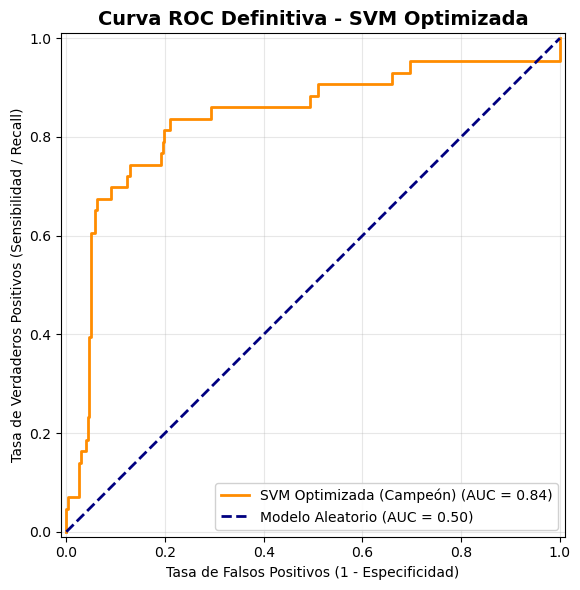


Área Bajo la Curva (AUC) Final: 0.8375


In [23]:
# =====================================================================
# 6. EVALUACIÓN FINAL: CURVA ROC Y AUC (Modelo Optimizado)
# =====================================================================
# El Pipeline final usa SVC sin probability=True, por lo que usamos
# decision_function (distancia al hiperplano), válido para ROC/AUC.
scores = modelo_definitivo.decision_function(X_test)

# Calcular las métricas para la curva
fpr, tpr, umbrales = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

# Configurar el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Trazar la curva ROC del modelo ganador (API actualizada)
roc_display = RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc,
    name='SVM Optimizada (Campeón)'
)
roc_display.plot(
    ax=ax,
    curve_kwargs={'color': 'darkorange', 'lw': 2}
)

# Trazar la línea de base (Modelo Aleatorio)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio (AUC = 0.50)')

# Mejorar la estética del gráfico
ax.set_title('Curva ROC Definitiva - SVM Optimizada', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
ax.legend(loc='lower right', framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()

# Mostrar gráfico y métrica final
plt.show()

print(f"\nÁrea Bajo la Curva (AUC) Final: {roc_auc:.4f}")

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import loguniform, uniform

# =====================================================================
# 1. CARGA DE DATOS: Regresión (Predecir Alcohol)
# =====================================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

X = wine_data.drop('alcohol', axis=1)
y = wine_data['alcohol'] # Variable continua

# =====================================================================
# 2. AISLAMIENTO DEL CONJUNTO DE PRUEBA
# =====================================================================
# Sin 'stratify' porque la variable objetivo es continua.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# =====================================================================
# 3. K-FOLD CROSS-VALIDATION PARA REGRESIÓN
# =====================================================================
# Usamos KFold estándar. shuffle=True es vital si los datos originales 
# tenían algún orden cronológico o agrupado.
cv_estrategia = KFold(n_splits=5, shuffle=True, random_state=42)

# =====================================================================
# 4. ESPACIO DE BÚSQUEDA SVR (C, Gamma, Epsilon)
# =====================================================================
espacio_parametros_svr = {
    'svr__kernel': ['rbf'],                 # Nos centramos en RBF para relaciones químicas complejas
    'svr__C': loguniform(1e-1, 1e2),        # Tolerancia: De 0.1 a 1000
    'svr__gamma': loguniform(1e-3, 1e0),    # Radio de influencia
    'svr__epsilon': uniform(0.15, 0.5)      # Ancho del tubo: de 0.01 a 0.51 (distribución uniforme)
}

# =====================================================================
# 5. OPTIMIZACIÓN (Buscando minimizar el Error)
# =====================================================================
busqueda_svr = RandomizedSearchCV(
    estimator=pipeline_svr,
    param_distributions=espacio_parametros_svr,
    n_iter=60,                  # Probamos 60 combinaciones
    cv=cv_estrategia,
    # ATENCIÓN: Scikit-learn siempre busca MAXIMIZAR la métrica.
    # Por eso, para minimizar el MAE, usamos 'neg_mean_absolute_error'
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Iniciando optimización SVR (Minimización de MAE)...")
busqueda_svr.fit(X_train, y_train)

# =====================================================================
# 6. ANÁLISIS DEL CAMPEÓN
# =====================================================================
print("\n=== HIPERPARÁMETROS DEL MEJOR MODELO SVR ===")
for param, valor in busqueda_svr.best_params_.items():
    if isinstance(valor, float):
        print(f" - {param}: {valor:.4f}")
    else:
        print(f" - {param}: {valor}")

# Revertimos el signo negativo que usó scikit-learn internamente
mejor_mae_cv = -busqueda_svr.best_score_ 
print(f"Mejor MAE (promedio K-Fold): {mejor_mae_cv:.4f} % vol")

# =====================================================================
# 7. LA PRUEBA DE FUEGO (X_TEST)
# =====================================================================
modelo_definitivo_svr = busqueda_svr.best_estimator_
predicciones_finales = modelo_definitivo_svr.predict(X_test)

print("\n=== REPORTE DEFINITIVO EN DATOS DE PRUEBA (X_TEST) ===")
print(f"MAE  (Error Absoluto Medio): {mean_absolute_error(y_test, predicciones_finales):.4f} % vol")
print(f"RMSE (Raíz Error Cuadrático): {np.sqrt(mean_squared_error(y_test, predicciones_finales)):.4f} % vol")
print(f"R^2  (Coef. Determinación): {r2_score(y_test, predicciones_finales):.4f}")

# Calcular porcentaje de Vectores de Soporte usados por el modelo final
n_sv = len(modelo_definitivo_svr.named_steps['svr'].support_)
porcentaje_sv = (n_sv / len(X_train)) * 100
print(f"\nComplejidad del Modelo: Usa el {porcentaje_sv:.1f}% de los datos de entrenamiento como Vectores de Soporte.")

Iniciando optimización SVR (Minimización de MAE)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== HIPERPARÁMETROS DEL MEJOR MODELO SVR ===
 - svr__C: 9.7178
 - svr__epsilon: 0.3059
 - svr__gamma: 0.0363
 - svr__kernel: rbf
Mejor MAE (promedio K-Fold): 0.3810 % vol

=== REPORTE DEFINITIVO EN DATOS DE PRUEBA (X_TEST) ===
MAE  (Error Absoluto Medio): 0.3563 % vol
RMSE (Raíz Error Cuadrático): 0.4695 % vol
R^2  (Coef. Determinación): 0.8229

Complejidad del Modelo: Usa el 49.2% de los datos de entrenamiento como Vectores de Soporte.


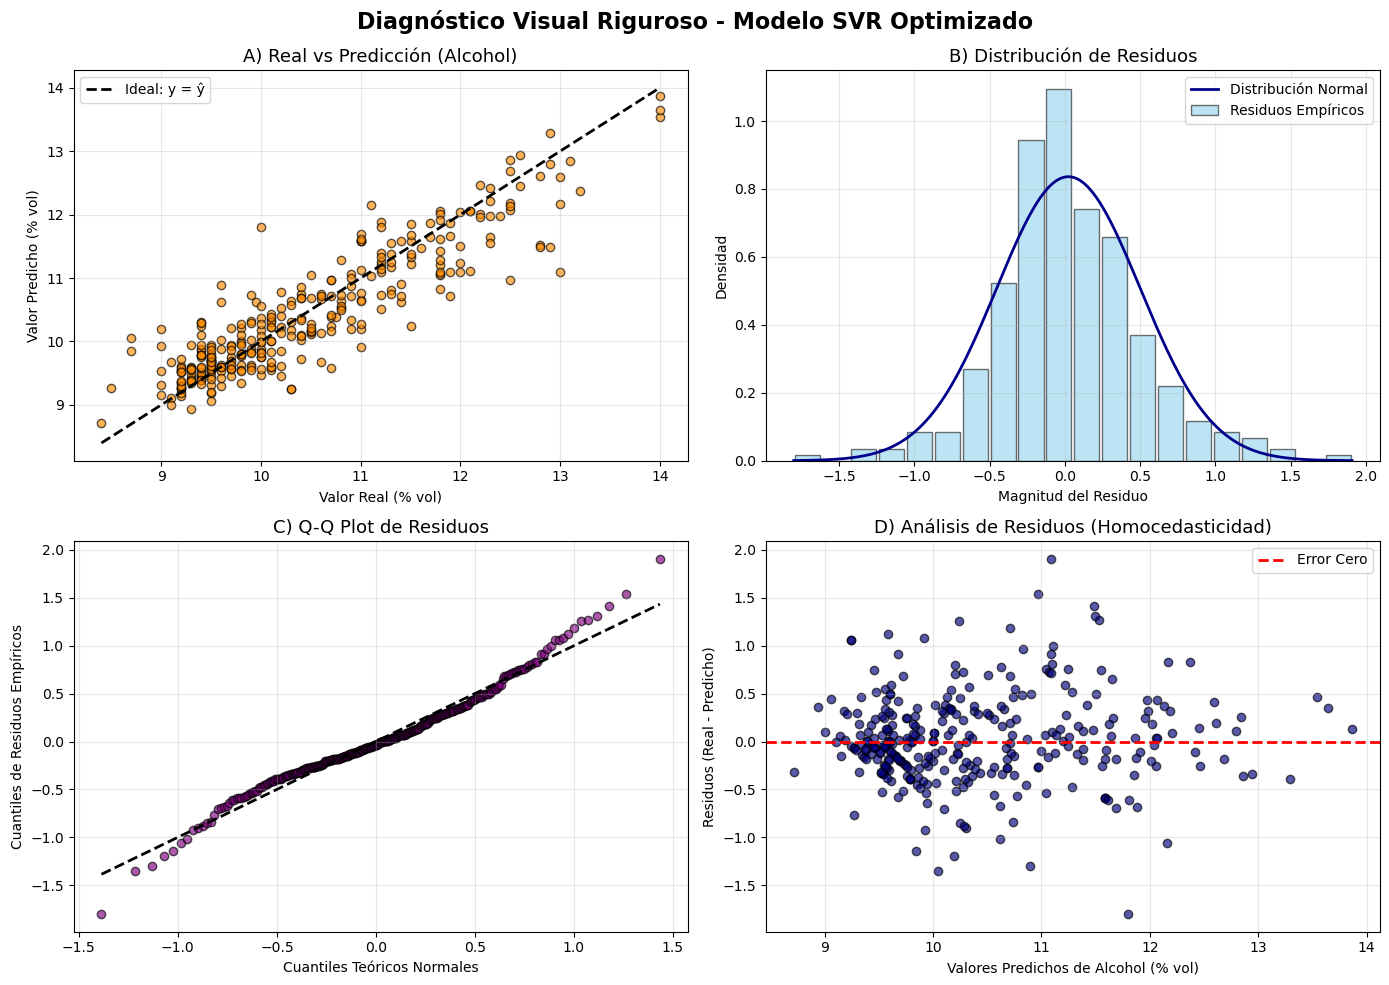

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats # Necesario para el cálculo exacto del Q-Q Plot

# =====================================================================
# 8. EVALUACIÓN VISUAL DEFINITIVA DEL MODELO SVR CAMPEÓN (PANEL 2x2)
# =====================================================================
# Utilizamos las predicciones generadas por el mejor estimador del RandomizedSearchCV
residuos = y_test - predicciones_finales

# Configurar el lienzo de gráficos 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Diagnóstico Visual Riguroso - Modelo SVR Optimizado', 
             fontsize=16, fontweight='bold', y=0.98)

# --- A) Real vs Predicción ---
ax1 = axes[0, 0]
ax1.scatter(y_test, predicciones_finales, alpha=0.65, color="darkorange", edgecolors='k')
min_v = min(y_test.min(), predicciones_finales.min())
max_v = max(y_test.max(), predicciones_finales.max())
ax1.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=2, label='Ideal: y = ŷ')
ax1.set_title('A) Real vs Predicción (Alcohol)', fontsize=13)
ax1.set_xlabel('Valor Real (% vol)')
ax1.set_ylabel('Valor Predicho (% vol)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# --- B) Distribución de Residuos (Histograma + Envolvente) ---
ax2 = axes[0, 1]
conteos, bins = np.histogram(residuos, bins=20, density=True)
centros = (bins[:-1] + bins[1:]) / 2
ancho = bins[1] - bins[0]
ax2.bar(centros, conteos, width=ancho * 0.9, alpha=0.55, color='skyblue', edgecolor='k', label='Residuos Empíricos')

# Cálculo de la envolvente normal teórica
mu, sigma = residuos.mean(), residuos.std(ddof=1)
x_env = np.linspace(residuos.min(), residuos.max(), 300)
envolvente = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_env - mu) / sigma) ** 2)
ax2.plot(x_env, envolvente, 'darkblue', linewidth=2, label='Distribución Normal')
ax2.set_title('B) Distribución de Residuos', fontsize=13)
ax2.set_xlabel('Magnitud del Residuo')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.grid(alpha=0.3)

# --- C) Gráfica Q-Q de Residuos (Cálculo Teórico Exacto) ---
ax3 = axes[1, 0]
res_ordenados = np.sort(residuos.values if hasattr(residuos, "values") else residuos)
n_res = len(res_ordenados)

# Generación de cuantiles teóricos deterministas (PPF)
proporciones = (np.arange(1, n_res + 1) - 0.5) / n_res
q_teoricos = stats.norm.ppf(proporciones, loc=mu, scale=sigma)

ax3.scatter(q_teoricos, res_ordenados, alpha=0.65, color="purple", edgecolors='k')
# Línea de referencia ideal
ax3.plot([q_teoricos.min(), q_teoricos.max()], [q_teoricos.min(), q_teoricos.max()], 'k--', linewidth=2)
ax3.set_title('C) Q-Q Plot de Residuos', fontsize=13)
ax3.set_xlabel('Cuantiles Teóricos Normales')
ax3.set_ylabel('Cuantiles de Residuos Empíricos')
ax3.grid(alpha=0.3)

# --- D) Residuos vs Predicción ---
ax4 = axes[1, 1]
ax4.scatter(predicciones_finales, residuos, alpha=0.65, color="navy", edgecolors='k')
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Error Cero')
ax4.set_title('D) Análisis de Residuos (Homocedasticidad)', fontsize=13)
ax4.set_xlabel('Valores Predichos de Alcohol (% vol)')
ax4.set_ylabel('Residuos (Real - Predicho)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
# Pequeño ajuste para que el suptitle no colisione con los gráficos
plt.subplots_adjust(top=0.92) 
plt.show()

# Predicción de datos biologicos con SVM 

Su tarea es automatizar el análisis de abulones utilizando Máquinas de Vectores de Soporte. Tradicionalmente, determinar la edad de un abulón requiere cortar su concha, teñirla y contar los anillos a través de un microscopio (un proceso lento y destructivo). Su misión es predecir esta información basándose únicamente en medidas físicas no destructivas (Longitud, Diámetro, Altura, Pesos).

1. ***Clasificación Binaria (SVC)***

El instituto necesita separar rápidamente los abulones jóvenes de los viejos para estudios de conservación.

* Crear una variable objetivo sintética. Si los Anillos (Rings) son $> 10$, clasificar como "Viejo" (1). Si son $\le 10$, clasificar como "Joven" (0).

* Construir un Pipeline que incluya StandardScaler. Manejar el desbalance de clases intrínseco (explorar el parámetro class_weight='balanced').Utilizar RandomizedSearchCV para optimizar $C$ y $\gamma$ usando un Kernel RBF. 

* Optimizar en base al F1-Score.

* Validar el modelo empleando: Matriz de Confusión y la Curva ROC con su AUC. 

2. ***Regresión***

Ahora se requiere predecir la edad biológica exacta (Número de Anillos) sin destruir la concha.

* Predecir la variable continua Rings usando Support Vector Regression.

* Utilizar una Validación Cruzada de 5 pliegues (K-Fold) estricta para evitar Fuga de Datos.

* Explorar el espacio tridimensional de SVR: $C$, $\gamma$, y el tubo de tolerancia $\epsilon$.

* Opcional: Implementar una métrica de puntuación (scorer) personalizada que penalice modelos que usen más del 60% de los datos como Vectores de Soporte.

* Validar el modelo empleando un reporte numérico con MedAE, RMSE y el $R^2$ Ajustado.

* Generar el panel de diagnóstico visual 2x2 (Real vs Predicción, Distribución de Residuos, Q-Q Plot y Análisis de Homocedasticidad).



In [28]:
import pandas as pd

# =====================================================================
# PASO 0: DESCARGA Y PREPARACIÓN DEL DATASET "ABALONE"
# =====================================================================
print("Descargando datos desde UCI Machine Learning Repository...")

# 1. Definir la URL directa del archivo de datos puro
url_abalone = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

# 2. El archivo original no tiene nombres de columnas, debemos especificarlos
nombres_columnas = [
    'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 
    'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'
]

# 3. Cargar el dataset en un DataFrame de Pandas
abalone_data = pd.read_csv(url_abalone, names=nombres_columnas)

# =====================================================================
# PREPROCESAMIENTO OBLIGATORIO PARA SVM
# =====================================================================
# Las Máquinas de Vectores de Soporte son algoritmos puramente espaciales (matemáticos).
# No entienden letras como 'M' (Macho) o 'F' (Hembra). 
# Convertimos la columna 'Sex' a columnas binarias usando One-Hot Encoding.
# Usamos drop_first=True para evitar la trampa de las variables ficticias (colinealidad).

abalone_data = pd.get_dummies(abalone_data, columns=['Sex'], drop_first=True)

# Veamos cómo quedó el dataset listo para el modelo
print("\nEstructura del Dataset procesado:")
print(abalone_data.head())
print(f"\nTamaño total del dataset: {abalone_data.shape[0]} abulones.")

# =====================================================================
# PREPARACIÓN DE LAS DOS MISIONES DEL PROYECTO
# =====================================================================

# --- MISIÓN 1: CLASIFICACIÓN (Joven vs Viejo) ---
# Creamos la variable objetivo: 1 si tiene más de 10 anillos (Viejo), 0 en caso contrario.
y_clasificacion = (abalone_data['Rings'] > 10).astype(int)
X_clasificacion = abalone_data.drop('Rings', axis=1)

print("\n--- Datos listos para Punto 1 (Clasificación) ---")
print(f"Distribución de clases:\n{y_clasificacion.value_counts(normalize=True) * 100}")
# ¡Atención estudiantes! Observen si las clases están balanceadas o no.

# --- MISIÓN 2: REGRESIÓN (Predicción exacta de la edad) ---
# La variable objetivo es el número exacto y continuo de anillos.
y_regresion = abalone_data['Rings']
X_regresion = abalone_data.drop('Rings', axis=1)

print("\n--- Datos listos para Punto 2 (Regresión) ---")
print("Las variables X_clasificacion, y_clasificacion, X_regresion e y_regresion están listas para usarse.")

Descargando datos desde UCI Machine Learning Repository...

Estructura del Dataset procesado:
   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  Sex_I  Sex_M  
0         0.150     15  False   True  
1         0.070      7  False   True  
2         0.210      9  False  False  
3         0.155     10  False   True  
4         0.055      7   True  False  

Tamaño total del dataset: 4177 abulones.

--- Datos listos para Punto 1 (Clasificación) ---
Distribución de clases:
Rings
0    65.357912
1    34.642088
Name: proportion, dtype: float64

--- Datos listos para 

In [ ]:
# Escribe tú código de clasificación aquí (Punto 1)

In [ ]:
# Escribe tú código de clasificación aquí (Punto 2)